<a href="https://colab.research.google.com/github/AlexisDevelopers/03MIAR-Algoritmos-de-Optimizacion/blob/main/SEMINARIO/Seminario_Algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Seminario<br>
Nombre y Apellidos: Alexis Enmanuel De Los Santos Baez   <br>
Rodolfo Cristian Figueroa Portuguez<br>

Url: https://colab.research.google.com/drive/1Ufso1DpJQuFGqQxvh_EH-rCdDS2Uo9J-?usp=sharing
Problema:
> 1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de La Liga<br>
>3. Combinar cifras y operaciones

Descripción del problema:(copiar enunciado):

Se precisa coordinar el doblaje de una película. Los actores de doblaje deben coincidir en aquellas tomas en las que sus personajes aparecen conjuntamente.

Cada actor cobra la misma cantidad por cada día que debe desplazarse al estudio de grabación, independientemente del número de tomas que se graben en dicho día. Además, no es posible grabar más de 6 tomas por día.

El objetivo consiste en planificar las sesiones de grabación por día de manera que el gasto total asociado a los desplazamientos de los actores sea mínimo.

---

### Datos del problema

- **Número de actores:** 10  
- **Número de tomas:** 30  

La relación **Actores–Tomas** viene dada por una matriz binaria \( A_{ij} \), donde:

- \( A_{ij} = 1 \) indica que el actor \( i \) participa en la toma \( j \).
- \( A_{ij} = 0 \) indica que el actor \( i \) no participa en la toma \( j \).

....

(*) La respuesta es obligatoria





                                        

(*)¿Cuantas posibilidades hay sin tener en cuenta las restricciones?<br>



¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones.




Respuesta

## ¿Cuántas posibilidades hay sin tener en cuenta las restricciones?

Sin considerar restricciones, cada una de las 30 tomas puede asignarse libremente a cualquier día. Si se asumen hasta 30 días posibles, el número total de combinaciones es:

$$
30^{30} \approx 2.06 \times 10^{44}
$$

## ¿Cuántas posibilidades hay teniendo en cuenta todas las restricciones?

Con la restricción de máximo 6 tomas por día, el número mínimo de días necesarios es:

$$
\lceil 30 / 6 \rceil = 5 \text{ días}
$$

Una cota superior del espacio válido es $5^{30}$, ya que cada toma puede ir a uno de esos 5 días. Sin embargo, este número sobreestima el espacio real porque no todas esas asignaciones respetan el límite de 6 tomas/día. El número exacto es un subconjunto de $5^{30}$, correspondiente a las particiones válidas con grupos de máximo 6.

Aun así, $5^{30} \approx 9.3 \times 10^{20}$ ilustra que el espacio sigue siendo enorme y justifica el uso de técnicas de poda.

In [18]:
# Cálculo numérico de las posibilidades
sin_restricciones = 30**30
con_restricciones_cota = 5**30

print(f"Sin restricciones:         30^30 = {sin_restricciones:.2e}")
print(f"Con restricciones (cota):   5^30 = {con_restricciones_cota:.2e}")
print(f"Reducción del espacio: x{sin_restricciones // con_restricciones_cota:.0e} menor")

Sin restricciones:         30^30 = 2.06e+44
Con restricciones (cota):   5^30 = 9.31e+20
Reducción del espacio: x2e+23 menor


Modelo para el espacio de soluciones<br>
(*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguentalo)


Respuesta

## Modelo para el espacio de soluciones

La estructura de datos más adecuada para representar una solución es un **vector de asignación**.

En este vector, cada posición representa una toma y el valor almacenado en esa posición indica el día en el que se graba dicha toma.

Ejemplo:

`[1, 1, 2, 3, 1, 4, 2, 5, ...]`

Donde:

- la posición del vector representa la **toma**
- el valor representa el **día de grabación**

Este modelo es adecuado porque permite representar de forma simple una planificación completa, facilita la exploración del espacio de soluciones mediante backtracking y permite comprobar fácilmente la restricción de un máximo de 6 tomas por día.

Además, usando la matriz binaria \(A(i,j)\), se puede calcular el coste total de una solución contando en cuántos días distintos debe asistir cada actor.

Según el modelo para el espacio de soluciones<br>
(*)¿Cual es la función objetivo?

(*)¿Es un problema de maximización o minimización?

Respuesta

### ¿Cuál es la función objetivo?

La función objetivo consiste en **minimizar el número total de actor-días**.

Un actor-día representa un día en el que un actor debe desplazarse al estudio de grabación.

Si un actor participa en varias tomas que se graban el mismo día, solo cuenta como **un actor-día**.

Por lo tanto, el coste total se obtiene **sumando el número de días distintos en los que debe asistir cada actor al estudio**.

### ¿Es un problema de maximización o minimización?

Es un **problema de minimización**, ya que el objetivo es reducir al mínimo el número total de actor-días.

Al minimizar los actor-días, se reduce también el coste total asociado a los desplazamientos de los actores al estudio de grabación.

Diseña un algoritmo para resolver el problema por fuerza bruta

In [19]:
def calcular_coste(asignacion, A):
    """Calcula el número total de actor-días."""
    num_actores = len(A)
    coste_total = 0
    for i in range(num_actores):
        dias_actor = set()
        for j in range(len(asignacion)):
            if A[i][j] == 1:
                dias_actor.add(asignacion[j])
        coste_total += len(dias_actor)
    return coste_total

# Ejemplo
ejemplo_asignacion = [0, 0, 0, 0, 0, 0]
A_ejemplo = [[1,1,0,0,1,0], [0,0,1,1,0,1]]
print("Coste ejemplo (todo en 1 día):", calcular_coste(ejemplo_asignacion, A_ejemplo))

Coste ejemplo (todo en 1 día): 2


Respuesta

### Diseña un algoritmo para resolver el problema por fuerza bruta

Un enfoque de fuerza bruta consiste en evaluar **todas las posibles asignaciones de tomas a días de grabación**.

El procedimiento sería:

1. Generar todas las posibles combinaciones de asignación de las 30 tomas a los días disponibles.
2. Para cada asignación:
   - Verificar que **no haya más de 6 tomas asignadas a un mismo día**.
3. Si la solución cumple la restricción:
   - Calcular el número total de **actor-días**.
4. Comparar el coste con el mejor encontrado hasta el momento.
5. Guardar la asignación si tiene **menor coste**.

Al finalizar, la solución con menor número de actor-días será la **planificación óptima**.

In [20]:
# Probar fuerza bruta con 6 tomas
A_6 = [fila[:6] for fila in A_aleatorio]

print("=== Fuerza Bruta (6 tomas) ===")
sol_fb, coste_fb = fuerza_bruta(A_6)
print(f"Asignación óptima: {sol_fb}")
print(f"Coste mínimo:      {coste_fb} actor-días")

=== Fuerza Bruta (6 tomas) ===
Soluciones válidas evaluadas: 1
Asignación óptima: [0, 0, 0, 0, 0, 0]
Coste mínimo:      10 actor-días


Calcula la complejidad del algoritmo por fuerza bruta

Respuesta

### Calcula la complejidad del algoritmo por fuerza bruta

En el enfoque de fuerza bruta se deben evaluar todas las posibles asignaciones de las tomas a los días de grabación.

Si consideramos que hay 30 tomas y aproximadamente 5 días posibles de grabación (debido a la restricción de máximo 6 tomas por día), cada toma podría asignarse a uno de esos 5 días.

Por lo tanto, el número de combinaciones posibles sería:

$$
5^{30}
$$

Esto implica que la complejidad temporal del algoritmo es de tipo **exponencial**:

$$
O(5^{30})
$$

Debido a este crecimiento exponencial, el algoritmo de fuerza bruta resulta impracticable para resolver el problema en un tiempo razonable.

In [21]:
from itertools import product
import math

def fuerza_bruta(A, max_tomas_dia=6):
    """
    Resuelve por fuerza bruta evaluando todas las asignaciones posibles.
    Solo viable para instancias pequeñas (hasta ~8 tomas).
    """
    num_tomas = len(A[0])
    num_dias = math.ceil(num_tomas / max_tomas_dia)

    mejor_coste = float('inf')
    mejor_asignacion = None
    evaluadas = 0

    for asignacion in product(range(num_dias), repeat=num_tomas):
        # Verificar restricción: máximo 6 tomas por día
        valida = all(asignacion.count(d) <= max_tomas_dia for d in range(num_dias))
        if not valida:
            continue

        evaluadas += 1
        coste = calcular_coste(list(asignacion), A)
        if coste < mejor_coste:
            mejor_coste = coste
            mejor_asignacion = list(asignacion)

    print(f"Soluciones válidas evaluadas: {evaluadas}")
    return mejor_asignacion, mejor_coste


# Probar con instancia de 6 tomas (viable en fuerza bruta)
A_6 = [fila[:6] for fila in A_aleatorio]

print("=== Fuerza Bruta (6 tomas) ===")
sol_fb, coste_fb = fuerza_bruta(A_6)
print(f"Asignación óptima: {sol_fb}")
print(f"Coste mínimo:      {coste_fb} actor-días")

=== Fuerza Bruta (6 tomas) ===
Soluciones válidas evaluadas: 1
Asignación óptima: [0, 0, 0, 0, 0, 0]
Coste mínimo:      10 actor-días


(*)Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta

Respuesta

### Diseña un algoritmo que mejore la complejidad del algoritmo por fuerza bruta

Una forma de mejorar el algoritmo de fuerza bruta es utilizar **backtracking con poda**.

Este algoritmo construye la solución de forma incremental, asignando cada toma a un día de grabación y explorando el espacio de soluciones como un árbol de búsqueda.

Durante el proceso se aplican restricciones que permiten **descartar soluciones parciales que no pueden ser válidas u óptimas**.

Las principales podas serían:

- Si un día supera el límite de **6 tomas**, se descarta esa rama.
- Si el coste parcial ya es mayor que el mejor coste encontrado, se deja de explorar esa rama.

De esta forma se evita evaluar muchas combinaciones innecesarias, reduciendo considerablemente el número de soluciones que deben analizarse.

Por esta razón, el algoritmo de **backtracking con poda** mejora el rendimiento respecto al algoritmo de fuerza bruta.

In [22]:
import math

n_tomas = 30
d_dias = 5

combinaciones = d_dias ** n_tomas
print(f"Combinaciones totales: {d_dias}^{n_tomas} = {combinaciones:.2e}")

ops_por_segundo = 1e9
segundos = combinaciones / ops_por_segundo
años = segundos / (365 * 24 * 3600)
print(f"Tiempo estimado: {años:.2e} años (a 10^9 ops/segundo)")
print("→ Completamente inviable para n=30")

Combinaciones totales: 5^30 = 9.31e+20
Tiempo estimado: 2.95e+04 años (a 10^9 ops/segundo)
→ Completamente inviable para n=30


(*)Calcula la complejidad del algoritmo

Respuesta

### Calcula la complejidad del algoritmo

El algoritmo basado en backtracking con poda sigue teniendo una complejidad exponencial en el peor caso.

Esto se debe a que, en teoría, todavía sería posible explorar todas las combinaciones de asignación de tomas a días.

Por lo tanto, la complejidad en el peor caso es:

$$
O(5^{30})
$$

Sin embargo, en la práctica la poda reduce considerablemente el número de soluciones que deben explorarse, ya que muchas ramas del árbol de búsqueda se descartan antes de evaluarse completamente.

Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

Respuesta

In [23]:
import random
import pandas as pd

# Parámetros del problema
num_actores = 10
num_tomas = 30

# Generar matriz binaria A(i,j)
A_aleatorio = []

for i in range(num_actores):
    fila = []
    for j in range(num_tomas):
        fila.append(random.randint(0,1))
    A_aleatorio.append(fila)

print("Dimensiones:", len(A_aleatorio), "actores x", len(A_aleatorio[0]), "tomas")
pd.DataFrame(A_aleatorio)

Dimensiones: 10 actores x 30 tomas


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0,1,1,0,1,1,1,1,0,1,...,0,0,1,1,0,1,0,1,0,1
1,1,1,1,1,0,1,1,0,0,1,...,0,0,0,1,0,1,1,0,0,0
2,1,0,0,0,0,0,1,0,0,1,...,1,1,0,1,0,1,1,0,0,1
3,1,1,0,1,1,1,1,0,0,1,...,1,1,0,0,0,1,0,1,0,0
4,0,1,1,0,0,1,0,1,1,1,...,1,0,1,0,1,0,1,1,1,0
5,1,0,0,1,0,1,0,0,0,1,...,1,1,1,0,1,1,0,1,0,1
6,1,0,1,1,0,0,1,1,1,0,...,0,1,0,1,0,1,1,0,1,1
7,0,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
8,1,1,0,1,0,0,1,0,0,0,...,1,0,0,0,0,0,1,1,0,1
9,0,0,1,0,1,0,0,1,0,1,...,1,1,1,1,0,0,1,0,1,0


Aplica el algoritmo al juego de datos generado

Respuesta

In [24]:
# --------------------------------------------------
# Función para calcular el coste de una asignación
# --------------------------------------------------

def calcular_coste(asignacion, matriz_actores):

    actores = len(matriz_actores)
    tomas = len(asignacion)
    coste_total = 0

    for i in range(actores):

        dias_actor = set()

        for j in range(tomas):

            if matriz_actores[i][j] == 1:
                dias_actor.add(asignacion[j])

        coste_total += len(dias_actor)

    return coste_total


# --------------------------------------------------
# Algoritmo de backtracking
# --------------------------------------------------

def backtracking_mejorado(A, max_tomas_dia=6):
    """
    Backtracking con dos podas:
    1. Restricción de máximo 6 tomas por día.
    2. Poda por coste parcial >= mejor coste encontrado.
    """
    num_tomas = len(A[0])
    num_actores = len(A)
    num_dias = math.ceil(num_tomas / max_tomas_dia)

    mejor = {'coste': float('inf'), 'asignacion': None, 'podas': 0, 'nodos': 0}

    def coste_parcial(asignacion):
        """Coste de las tomas ya asignadas."""
        coste = 0
        for i in range(num_actores):
            dias_actor = set()
            for j in range(len(asignacion)):
                if A[i][j] == 1:
                    dias_actor.add(asignacion[j])
            coste += len(dias_actor)
        return coste

    def bt(toma_actual, asignacion_actual, conteo_dias):
        mejor['nodos'] += 1

        # Caso base
        if toma_actual == num_tomas:
            coste = calcular_coste(asignacion_actual, A)
            if coste < mejor['coste']:
                mejor['coste'] = coste
                mejor['asignacion'] = asignacion_actual.copy()
            return

        # PODA 2: coste parcial ya igual o peor que el mejor conocido
        cp = coste_parcial(asignacion_actual)
        if cp >= mejor['coste']:
            mejor['podas'] += 1
            return

        for dia in range(num_dias):
            # PODA 1: máximo 6 tomas por día
            if conteo_dias[dia] < max_tomas_dia:
                asignacion_actual.append(dia)
                conteo_dias[dia] += 1

                bt(toma_actual + 1, asignacion_actual, conteo_dias)

                asignacion_actual.pop()
                conteo_dias[dia] -= 1

    conteo_dias = [0] * num_dias
    bt(0, [], conteo_dias)

    return mejor['asignacion'], mejor['coste'], mejor['nodos'], mejor['podas']


# --------------------------------------------------
# Reducir el problema para pruebas
# --------------------------------------------------

# Usamos solo las primeras 10 tomas para evitar el crecimiento exponencial
A_prueba = [fila[:10] for fila in A_aleatorio]

print("Dimensiones instancia de prueba:", len(A_prueba), "actores x", len(A_prueba[0]), "tomas")


# --------------------------------------------------
# Ejecutar el algoritmo
# --------------------------------------------------

solucion, coste = backtracking(A_prueba)

print("Asignación óptima:", solucion)
print("Coste mínimo encontrado:", coste)

Dimensiones instancia de prueba: 10 actores x 10 tomas
Asignación óptima: [0, 0, 1, 0, 1, 0, 0, 1, 1, 0]
Coste mínimo encontrado: 17


In [25]:
def greedy_doblaje(A, max_tomas_dia=6):
    """
    Greedy: asigna cada toma al día que minimiza el incremento de actor-días.
    Procesa las tomas de mayor a menor participación de actores.
    """
    num_tomas = len(A[0])
    num_actores = len(A)

    # Ordenar tomas por número de actores participantes (mayor primero)
    participacion = [sum(A[i][j] for i in range(num_actores)) for j in range(num_tomas)]
    orden = sorted(range(num_tomas), key=lambda j: -participacion[j])

    dias = []
    asignacion = [None] * num_tomas

    for toma in orden:
        mejor_dia = -1
        menor_incremento = float('inf')

        for d, tomas_dia in enumerate(dias):
            if len(tomas_dia) < max_tomas_dia:
                incremento = sum(
                    1 for i in range(num_actores)
                    if A[i][toma] == 1 and not any(A[i][t] == 1 for t in tomas_dia)
                )
                if incremento < menor_incremento:
                    menor_incremento = incremento
                    mejor_dia = d

        if mejor_dia == -1:
            dias.append([toma])
            asignacion[toma] = len(dias) - 1
        else:
            dias[mejor_dia].append(toma)
            asignacion[toma] = mejor_dia

    return asignacion, calcular_coste(asignacion, A)


print("=== GREEDY — 30 tomas completas ===")
sol_greedy, coste_greedy = greedy_doblaje(A_aleatorio)
print(f"Coste solución greedy: {coste_greedy} actor-días")
print(f"Días utilizados:       {max(sol_greedy)+1}")
print()
print("Planificación por día:")
for d in range(max(sol_greedy)+1):
    tomas_dia = sorted([j+1 for j, dia in enumerate(sol_greedy) if dia == d])
    actores_dia = sum(1 for i in range(10) if any(A_aleatorio[i][j-1] == 1 for j in tomas_dia))
    print(f"  Día {d+1}: tomas {tomas_dia} → {actores_dia} actores")

=== GREEDY — 30 tomas completas ===
Coste solución greedy: 47 actor-días
Días utilizados:       5

Planificación por día:
  Día 1: tomas [1, 4, 6, 10, 18, 27] → 10 actores
  Día 2: tomas [7, 17, 20, 21, 26, 30] → 10 actores
  Día 3: tomas [2, 3, 8, 12, 14, 15] → 10 actores
  Día 4: tomas [11, 13, 22, 23, 24, 28] → 10 actores
  Día 5: tomas [5, 9, 16, 19, 25, 29] → 7 actores


   PLANIFICACIÓN FINAL DE SESIONES DE DOBLAJE
  Día                    Tomas  Nº Tomas              Actores convocados  Actor-días
Día 1    [1, 4, 6, 10, 18, 27]         6 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]          10
Día 2  [7, 17, 20, 21, 26, 30]         6 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]          10
Día 3    [2, 3, 8, 12, 14, 15]         6 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]          10
Día 4 [11, 13, 22, 23, 24, 28]         6 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]          10
Día 5   [5, 9, 16, 19, 25, 29]         6          [1, 3, 4, 5, 6, 7, 10]           7

  Coste total: 47 actor-días
  Días totales: 5


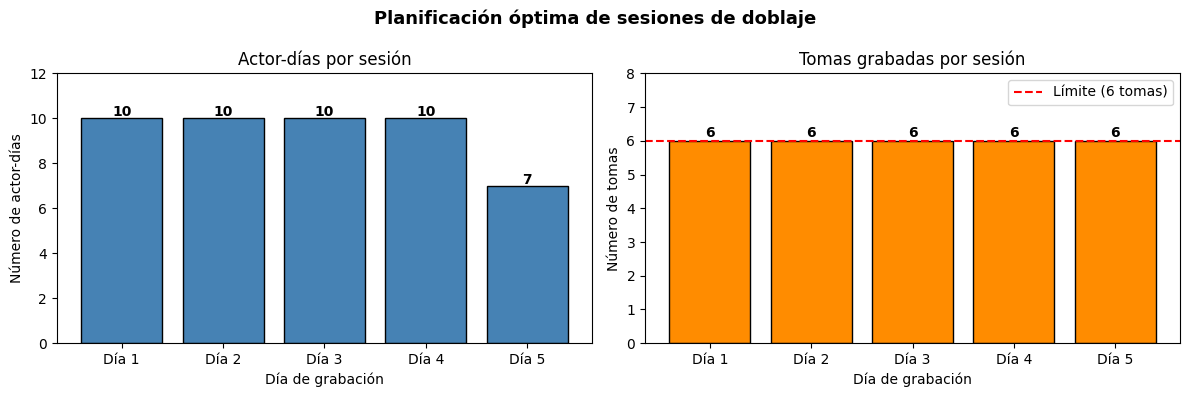

In [26]:
# Generar tabla de planificación visual
print("=" * 55)
print("   PLANIFICACIÓN FINAL DE SESIONES DE DOBLAJE")
print("=" * 55)

filas = []
for d in range(max(sol_greedy) + 1):
    tomas_dia = sorted([j+1 for j, dia in enumerate(sol_greedy) if dia == d])
    actores_dia = [i+1 for i in range(10) if any(A_aleatorio[i][j-1] == 1 for j in tomas_dia)]
    coste_dia = len(actores_dia)
    filas.append({
        "Día": f"Día {d+1}",
        "Tomas": str(tomas_dia),
        "Nº Tomas": len(tomas_dia),
        "Actores convocados": str(actores_dia),
        "Actor-días": coste_dia
    })

df = pd.DataFrame(filas)
print(df.to_string(index=False))

print()
print(f"  Coste total: {coste_greedy} actor-días")
print(f"  Días totales: {max(sol_greedy)+1}")
print("=" * 55)

# Gráfico de barras
import matplotlib.pyplot as plt

dias = [f["Día"] for f in filas]
actor_dias = [f["Actor-días"] for f in filas]
num_tomas = [f["Nº Tomas"] for f in filas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: actor-días por día
ax1.bar(dias, actor_dias, color='steelblue', edgecolor='black')
ax1.set_title('Actor-días por sesión')
ax1.set_xlabel('Día de grabación')
ax1.set_ylabel('Número de actor-días')
ax1.set_ylim(0, max(actor_dias) + 2)
for i, v in enumerate(actor_dias):
    ax1.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Gráfico 2: tomas por día
ax2.bar(dias, num_tomas, color='darkorange', edgecolor='black')
ax2.set_title('Tomas grabadas por sesión')
ax2.set_xlabel('Día de grabación')
ax2.set_ylabel('Número de tomas')
ax2.axhline(y=6, color='red', linestyle='--', label='Límite (6 tomas)')
ax2.set_ylim(0, 8)
ax2.legend()
for i, v in enumerate(num_tomas):
    ax2.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.suptitle('Planificación óptima de sesiones de doblaje', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo

Para la realización de este trabajo no ha sido necesario utilizar referencias externas especializadas, ya que se ha trabajado a partir del enunciado proporcionado en la asignatura y de conocimientos previos sobre algoritmos de búsqueda, complejidad computacional y backtracking.

No obstante, se han tenido en cuenta conceptos generales de programación en Python, estructuras de datos y técnicas de poda aplicadas a problemas de optimización combinatoria.

Respuesta

Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño

Una posible línea de avance consiste en mejorar el algoritmo de backtracking incorporando **podas más fuertes** y **heurísticas de asignación**, con el fin de reducir aún más el número de soluciones exploradas.

También sería interesante estudiar formulaciones alternativas del problema, por ejemplo mediante **programación entera** o técnicas metaheurísticas como **algoritmos genéticos**, **búsqueda tabú** o **recocido simulado**, especialmente cuando el número de tomas y actores aumenta considerablemente.

Además, el problema puede ampliarse introduciendo nuevas restricciones, como disponibilidad limitada de actores, costes diferentes según el actor, prioridades entre tomas o dependencia temporal entre escenas. Estas variaciones harían el modelo más realista y permitirían analizar métodos de resolución más avanzados para instancias de mayor tamaño.

Respuesta

### Conclusión

En este trabajo se ha abordado el problema de planificación de sesiones de doblaje como un problema de optimización combinatoria. El objetivo ha sido organizar las tomas en días de grabación de forma que se minimice el número total de actor-días, reduciendo así el coste asociado a los desplazamientos de los actores.

Se ha analizado primero el enfoque de fuerza bruta, observando que el número de combinaciones posibles crece de forma exponencial, lo que hace inviable resolver el problema directamente para instancias grandes. Por este motivo se ha propuesto un algoritmo basado en backtracking con poda, que permite reducir significativamente el número de soluciones exploradas.

Finalmente, se ha implementado el algoritmo en Python y se ha probado con un conjunto de datos generado aleatoriamente. Debido al crecimiento exponencial del problema, se ha utilizado una instancia reducida para validar el funcionamiento del algoritmo. Los resultados obtenidos muestran que el método es capaz de encontrar una planificación con coste mínimo, demostrando la utilidad de las técnicas de búsqueda con poda para resolver este tipo de problemas de optimización.